In [1]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import json
from pathlib import Path
import requests

# --- Configuration ---
ZOTERO_GROUP_ID = 5985739
OUTFILE = "../files/zotero_group_library.bib"
ZOTERO_JSON_OUTFILE = "../files/zotero-items.json"

# Zotero group API URL for BibTeX output
url = f"https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=biblatex&limit=5000"
zotero_json_url = f"https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100"


def resolve_zotero_items_path():
    cwd = Path.cwd()
    path_candidates = [
        cwd / "../files/zotero-items.json",
        cwd / "card-lab.github.io/files/zotero-items.json",
        cwd / "files/zotero-items.json",
    ]

    for candidate in path_candidates:
        if candidate.exists():
            return candidate.resolve()

    return path_candidates[0].resolve()


# Zotero returns results paginated — we'll loop until no "next" link
def download_full_bibtex():
    session = requests.Session()
    all_bib = ""
    next_url = url

    while next_url:
        print(f"Fetching: {next_url}")
        r = session.get(next_url)
        if r.status_code != 200:
            raise RuntimeError(f"Error {r.status_code}: {r.text}")

        # Append BibTeX text
        all_bib += r.text.strip() + "\n\n"

        # Check for pagination
        links = r.links
        if "next" in links:
            next_url = links["next"]["url"]
        else:
            next_url = None

    return all_bib


def download_full_zotero_items():
    session = requests.Session()
    items = []
    next_url = zotero_json_url

    while next_url:
        print(f"Fetching Zotero JSON: {next_url}")
        r = session.get(next_url, timeout=30)
        if r.status_code != 200:
            raise RuntimeError(f"Error {r.status_code}: {r.text}")

        items.extend(r.json())

        links = r.links
        if "next" in links:
            next_url = links["next"]["url"]
        else:
            next_url = None

    return items


def load_zotero_items():
    zotero_items_path = resolve_zotero_items_path()
    if zotero_items_path.exists():
        with open(zotero_items_path, "r", encoding="utf-8") as f:
            return json.load(f)

    items = download_full_zotero_items()
    zotero_items_path.parent.mkdir(parents=True, exist_ok=True)
    with open(zotero_items_path, "w", encoding="utf-8") as f:
        json.dump(items, f, ensure_ascii=True, indent=2)
    print(f"Saved fallback Zotero JSON to {zotero_items_path}")
    return items


if __name__ == "__main__":
    bibtex_data = download_full_bibtex()
    with open(OUTFILE, "w", encoding="utf-8") as f:
        f.write(bibtex_data)
    print(f"Saved Zotero library to {OUTFILE}")

%conda install bibtexparser wordcloud

Fetching: https://api.zotero.org/groups/5985739/items?format=biblatex&limit=5000
Fetching: https://api.zotero.org/groups/5985739/items?format=biblatex&limit=100&start=100
Saved Zotero library to ../files/zotero_group_library.bib
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


## At a glance

In [2]:
#| echo: false
#| output: true
#| eval: true

import json
from pathlib import Path
import requests
import plotly.graph_objects as go
import numpy as np
from IPython.display import HTML


def make_sparkline(data, color="white"):
    """Return Plotly sparkline HTML."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        y=data, mode="lines", line=dict(color=color, width=2)
    ))
    fig.update_layout(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0),
        height=80,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)"
    )
    return fig.to_html(include_plotlyjs=False, full_html=False)


def make_value_box(title, value, icon_name, theme, decimals=1):
    """Return HTML for a value box with an icon."""
    return f"""
    <div class="value-box {theme}">
      <div class="top-row">
        <div class="label">{title}</div>
        <iconify-icon icon="{icon_name}"></iconify-icon>
      </div>
      <div class="value">{value:.{decimals}f}</div>
    </div>
    """


ZOTERO_GROUP_ID = 5985739


def load_zotero_items_for_counts():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            items = json.load(f)
        return items

    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    return items


def count_in_zotero(items, item_types):
    wanted = {item_type.strip().lower() for item_type in item_types}
    count = 0
    for item in items:
        data = item.get("data", {})
        item_type = str(data.get("itemType", "")).strip().lower()
        if item_type in wanted:
            count += 1
    return count


zotero_items = load_zotero_items_for_counts()

# Get stats from Zotero JSON item types instead of BibTeX entry tags.
npres = count_in_zotero(zotero_items, ["presentation", "conferencepaper"])
ntheses = count_in_zotero(zotero_items, ["thesis"])
npapers = count_in_zotero(zotero_items, ["journalarticle"])
ncod = count_in_zotero(zotero_items, ["computerprogram", "dataset"])

# Build multiple boxes
boxes_html = f"""
<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(280px,1fr));gap:1rem;">
  {make_value_box("Peer-reviewed papers published since 2022", npapers, "fluent:document-sparkle-24-regular", "success", decimals=0)}
  {make_value_box("Conference presentations given since 2022", npres, "hugeicons:presentation-online", "info", decimals=0)}
  {make_value_box("Theses & dissertations published since 2022", ntheses, "lets-icons:book-fill", "warning", decimals=0)}
  {make_value_box("Datasets and open-source codes published since 2022", ncod, "carbon:db2-data-sharing-group", "danger", decimals=0)}
</div>
"""

HTML(boxes_html)

## Word cloud from titles and abstracts

Loaded Zotero items from API: 126 records
Loaded 93 textual Zotero records from 8 item types.
Included item types: computerprogram, conferencepaper, journalarticle, manuscript, preprint, presentation, report, thesis


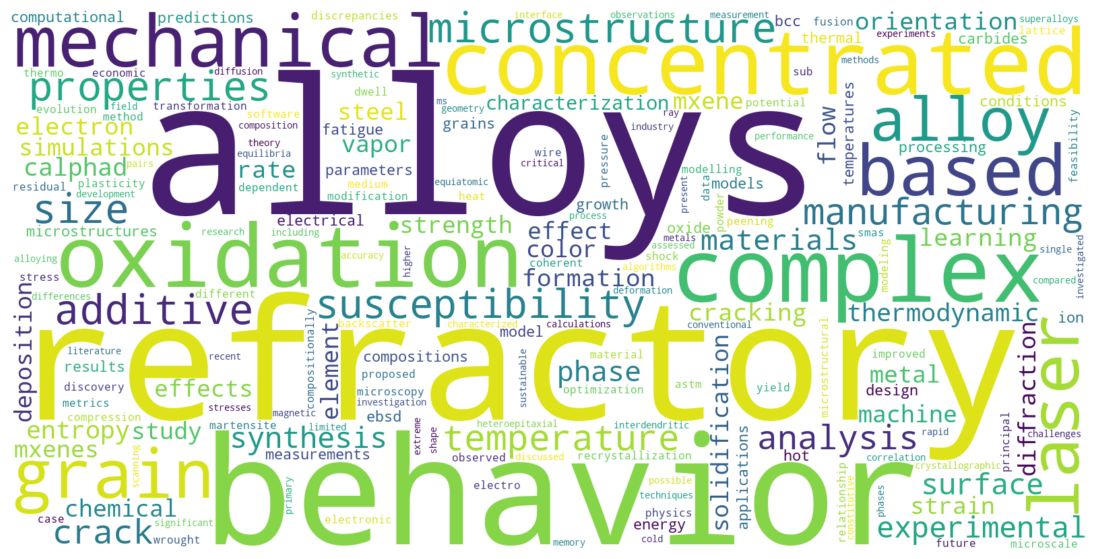

In [3]:
#| output: true

import json
from pathlib import Path
import requests
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ----------------------------
# Configuration
# ----------------------------
ZOTERO_GROUP_ID = 5985739
exclude_terms = ['doi', 'et', 'one', 'two', 'x', 'giorjao', 'org', 'h3', 'm', 'by', 'the', 'and', 'of', 'in', 'for', 'to', 'a', 'is', 'on', 'with', 'as', 'that', 'this', 'from', 'at', 'an', 'it', 'are', 'be', 'or', 'not', 'all', 'has', 'was', 'we', 'which', 'can', 't4', '6al', '4v', 'nb2co2', 'nb2c', 'well', 'y', 'cdf', 'paper', 'along', 'lower', 'show', 'small', 'pag', 'lineal', 'suggest', 'H', 'He', 'B', 'C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'Li', 'Na', 'K', 'Ca', 'Mg', 'Al', 'Si', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ti', 'Nb', 'Mo', 'W', 'Pd', 'Ag', 'Au', 'Pt', 'Hg', 'Pb', 'Bi', 'Ta', 'Hf', 'Zr', 'Sc', 'Y', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Re', 'Os', 'Ir', 'Ru', 'Rh', 'Tc', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Xe', 'Rn', 'alpha', 'beta', 'gamma', 'delta', 'epsilon', 'zeta', 'eta', 'theta', 'iota', 'kappa', 'lambda', 'mu', 'nu', 'xi', 'omicron', 'pi', 'rho', 'sigma', 'tau', 'upsilon', 'phi', 'chi', 'psi', 'omega', 'cvd', 'multi', 'due', 'also', 'new', 'use', 'may', 'could', 'would', 'should', 'must', 'need', 'like', 'get', 'make', 'see', 'know', 'want', 'think', 'say', 'go', 'come', 'take', 'give', 'despite', 'although', 'however', 'therefore', 'thus', 'hence', 'meanwhile', 'furthermore', 'moreover', 'additionally', 'consequently', 'accordingly', 'subsequently', 'eventually', 'finally', 'lastly', 'fem', 'nbti', 'rheas', 'work', 'monbti', 'used', 'bed', 'low', 'herx', 'using', 'high', 'rccas', 'approach', 'af', 'spg', 'ded', 'sem']


def load_zotero_items():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            items = json.load(f)
        print(f'Loaded Zotero items from file: {found}')
        return items

    # Fallback: fetch directly from Zotero API if local JSON is not present.
    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    if not items:
        candidate_text = '\n'.join(str(p.resolve()) for p in path_candidates)
        raise FileNotFoundError(
            'Could not locate local zotero-items.json and API fetch returned no records. Tried:\n' + candidate_text
        )

    print(f'Loaded Zotero items from API: {len(items)} records')
    return items


# ----------------------------
# Step 1: Read Zotero records
# ----------------------------
zotero_items = load_zotero_items()

# ----------------------------
# Step 2: Extract documents (title + abstract + tags)
# Includes theses/software/reports and other non-attachment item types.
# ----------------------------
documents = []
included_types = set()

for item in zotero_items:
    data = item.get('data', {})
    item_type = str(data.get('itemType', '')).strip().lower()

    # Skip non-scholarly container records.
    if item_type in {'attachment', 'note', 'annotation'}:
        continue

    text_parts = []

    title = str(data.get('title', '')).strip()
    abstract = str(data.get('abstractNote', '')).strip()
    tags = [
        str(t.get('tag', '')).strip()
        for t in data.get('tags', [])
        if str(t.get('tag', '')).strip()
    ]

    if title:
        text_parts.append(title)
    if abstract:
        text_parts.append(abstract)
    if tags:
        text_parts.append(' '.join(tags))

    if text_parts:
        documents.append(' '.join(text_parts))
        included_types.add(item_type or 'unknown')

if not documents:
    raise ValueError('No textual Zotero records found for word cloud generation.')

print(f'Loaded {len(documents)} textual Zotero records from {len(included_types)} item types.')
print('Included item types:', ', '.join(sorted(included_types)))

# ----------------------------
# Step 3: Compute TF-IDF
# ----------------------------
vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'
)

tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

# Compute total TF-IDF score per term (sum over all documents)
scores = tfidf_matrix.sum(axis=0).A1
tfidf_scores = dict(zip(feature_names, scores))

# Remove excluded terms
for term in exclude_terms:
    tfidf_scores.pop(term.lower(), None)

# ----------------------------
# Step 4: Create Word Cloud
# ----------------------------
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    collocations=False
).generate_from_frequencies(tfidf_scores)

# ----------------------------
# Step 5: Display
# ----------------------------
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [4]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import json
import requests
import pandas as pd
import time
from pathlib import Path

# ----------------------------
# Config
# ----------------------------
ZOTERO_GROUP_ID = 5985739
REFERENCES_WE_CITED_CSV_PATH = Path("../files/references_we_cited.csv")
REFERENCE_COLUMNS = [
    "citing_doi",
    "ref_doi",
    "ref_key",
    "ref_author",
    "ref_year",
    "ref_title",
    "ref_journal",
    "raw",
]


def load_reference_source_items():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            return json.load(f)

    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    return items


zotero_items = load_reference_source_items()
dois = sorted({
    str(item.get("data", {}).get("DOI", "")).strip().lower().replace("https://doi.org/", "").replace("http://doi.org/", "")
    for item in zotero_items
    if str(item.get("data", {}).get("DOI", "")).strip()
})

email = "paytonej@ucmail.uc.edu"  # Recommended for polite API usage
delay_seconds = 1.0               # Pause between requests to avoid rate limiting

if REFERENCES_WE_CITED_CSV_PATH.exists():
    existing_refs_df = pd.read_csv(REFERENCES_WE_CITED_CSV_PATH)
else:
    existing_refs_df = pd.DataFrame(columns=REFERENCE_COLUMNS)

for column in REFERENCE_COLUMNS:
    if column not in existing_refs_df.columns:
        existing_refs_df[column] = pd.NA


def _has_complete_reference_rows(df):
    if df.empty:
        return False

    completeness = df[REFERENCE_COLUMNS].fillna("").astype(str).apply(lambda col: col.str.strip() != "")
    return bool(completeness.all(axis=1).all())


# ----------------------------
# Helper function to get references for a DOI
# ----------------------------
def get_references_for_doi(doi):
    cached_rows = existing_refs_df.loc[existing_refs_df["citing_doi"] == doi].copy()
    if _has_complete_reference_rows(cached_rows):
        print(f"Using cached complete references for {doi}")
        return cached_rows[REFERENCE_COLUMNS].to_dict("records")

    url = f"https://api.crossref.org/works/{doi}"
    headers = {"User-Agent": f"Python script (mailto:{email})"}
    r = requests.get(url, headers=headers)

    if r.status_code != 200:
        print(f"Failed to fetch {doi}: HTTP {r.status_code}")
        return []

    data = r.json().get("message", {})
    references = data.get("reference", [])

    ref_list = []
    for ref in references:
        ref_list.append({
            "citing_doi": doi,
            "ref_doi": ref.get("DOI"),
            "ref_key": ref.get("key"),
            "ref_author": ref.get("author"),
            "ref_year": ref.get("year"),
            "ref_title": ref.get("article-title"),
            "ref_journal": ref.get("journal-title"),
            "raw": ref.get("unstructured")  # fallback
        })

    return ref_list

# ----------------------------
# Main script
# ----------------------------
all_refs = []
for doi in dois:
    refs = get_references_for_doi(doi)
    all_refs.extend(refs)
    time.sleep(delay_seconds)  # be polite to the API

df_refs = pd.DataFrame(all_refs)

# Save to CSV for later analysis
df_refs.to_csv("../files/references_we_cited.csv", index=False)

print(f"Loaded {len(dois)} DOI(s) from Zotero records")
print(df_refs)

Failed to fetch 10.1007/s11669-026-01250-6: HTTP 404
Failed to fetch 10.21949/rfzv-6285: HTTP 404
Failed to fetch 10.21949/tzgj-rk36: HTTP 404
Failed to fetch 10.5281/zenodo.16541961: HTTP 404
Loaded 22 DOI(s) from Zotero records
                       citing_doi                           ref_doi ref_key  \
0    10.1007/978-3-031-63937-1_73                              None  73_CR1   
1    10.1007/978-3-031-63937-1_73     10.1016/S0142-1123(97)00034-0  73_CR2   
2    10.1007/978-3-031-63937-1_73     10.1016/j.actamat.2012.01.049  73_CR3   
3    10.1007/978-3-031-63937-1_73      10.1016/j.matdes.2018.02.048  73_CR4   
4    10.1007/978-3-031-63937-1_73  10.1016/j.scriptamat.2017.04.018  73_CR5   
..                            ...                               ...     ...   
818            10.3390/ma16041549      10.1016/0375-9601(75)90130-9  ref_91   
819            10.3390/ma16041549        10.1088/0305-4470/16/4/016  ref_92   
820            10.3390/ma16041549         10.1007/s11467-01

In [5]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import requests
import pandas as pd
import time

email = "paytonej@ucmail.uc.edu"  # Recommended for polite API usage
delay_seconds = 1.0               # Pause between requests to avoid rate limiting


def get_citing_documents(doi):
    # Base URL for the OpenCitations REST API
    base_url = 'https://opencitations.net/index/api/v1/citations/'

    # Full URL with the DOI
    url = f'{base_url}{doi}'

    try:
        headers = {"User-Agent": f"Python script (mailto:{email})"}
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Check for HTTP errors

        # Extract the DOI strings of papers citing this DOI.
        citing_dois = []
        for ref in response.json():
            citing = ref.get('citing')
            if citing:
                citing = str(citing).strip().lower().replace('https://doi.org/', '').replace('http://doi.org/', '')
                if citing:
                    citing_dois.append(citing)

        return citing_dois

    except requests.exceptions.RequestException as e:
        print(f"An error occurred: {e}")
        return []


# Build the list of DOI records citing CARD Lab papers.
all_citing_dois = []
for doi in dois:
    all_citing_dois.extend(get_citing_documents(doi))
    time.sleep(delay_seconds)  # be polite to the API

# Unique citing DOIs for stable downstream processing.
unique_citing_dois = sorted(set(all_citing_dois))
print(f"Found {len(unique_citing_dois)} unique DOI(s) citing CARD Lab publications")

# Reuse the same reference extractor used in Cell 7 so both datasets have matching fields.
all_refs = []
for citing_doi in unique_citing_dois:
    refs = get_references_for_doi(citing_doi)
    all_refs.extend(refs)
    time.sleep(delay_seconds)  # be polite to the API

df_refs = pd.DataFrame(all_refs)

# Save to CSV for later analysis
df_refs.to_csv("../files/references_citing_us.csv", index=False)
print(df_refs)

Found 26 unique DOI(s) citing CARD Lab publications
                  citing_doi                        ref_doi      ref_key  \
0     10.1002/adem.202500508  10.1016/j.actamat.2020.05.003  e_1_2_9_2_1   
1     10.1002/adem.202500508  10.1016/j.actamat.2023.119401  e_1_2_9_3_1   
2     10.1002/adem.202500508             10.1038/ncomms7529  e_1_2_9_4_1   
3     10.1002/adem.202500508                           None  e_1_2_9_5_1   
4     10.1002/adem.202500508  10.1016/j.actamat.2024.119952  e_1_2_9_6_1   
...                      ...                            ...          ...   
1413    10.2139/ssrn.5160413  10.1016/S0921-5093(99)00368-8        ref57   
1414    10.2139/ssrn.5160413              10.1063/1.3486212        ref58   
1415    10.2139/ssrn.5160413     10.1016/j.msea.2003.06.004        ref59   
1416    10.2139/ssrn.5160413  10.1016/j.actamat.2017.12.011        ref60   
1417    10.2139/ssrn.5160413  10.1016/j.jallcom.2012.01.007        ref61   

     ref_author ref_year           

In [ ]:
#| output: false
#| eval: true
#| include: false
#| context: setup

import time
import requests
import pandas as pd
import plotly.express as px

USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
REQUEST_DELAY_SECONDS = 0.2


def normalize_doi(value):
    if not value:
        return None
    doi = str(value).strip()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    doi = doi.lower()
    return doi if doi else None


def _get_institution_geo(institution_id, headers, cache):
    """Fetch and cache location data for an OpenAlex institution ID."""
    if not institution_id:
        return None
    if institution_id in cache:
        return cache[institution_id]
    api_url = institution_id.replace("https://openalex.org/", "https://api.openalex.org/")
    try:
        r = requests.get(api_url, headers=headers, timeout=30)
        r.raise_for_status()
        inst = r.json()
        geo = inst.get("geo") or {}
        payload = {
            "affiliation": str(inst.get("display_name") or ""),
            "latitude": geo.get("latitude"),
            "longitude": geo.get("longitude"),
            "affiliation_city": geo.get("city") or "",
            "affiliation_state": geo.get("region") or "",
            "affiliation_country": geo.get("country") or str(inst.get("country_code") or ""),
        }
        cache[institution_id] = payload
        time.sleep(REQUEST_DELAY_SECONDS)
        return payload
    except Exception:
        cache[institution_id] = None
        return None


def _extract_openalex_work_fields(work):
    """Return (title, year, journal, keywords_list) from an OpenAlex work object."""
    title = str(work.get("display_name") or "")
    year = work.get("publication_year")

    journal = None
    source = (work.get("primary_location") or {}).get("source") or {}
    if source.get("display_name"):
        journal = str(source["display_name"]).strip() or None

    keywords = sorted({
        str(k.get("display_name")).strip()
        for k in (work.get("keywords") or [])
        if k.get("display_name")
    })
    if not keywords:
        keywords = sorted({
            str(c.get("display_name")).strip()
            for c in (work.get("concepts") or [])
            if c.get("display_name")
        })

    return title, year, journal, keywords


def build_comprehensive_rows(dois):
    """
    Fetch all metadata from OpenAlex in one call per DOI.

    Returns a list of row dicts — one row per (doi, author, affiliation) — with:
        doi, title, publication_year, journal_name, keywords,
        author_name, affiliation, affiliation_city, affiliation_state,
        affiliation_country, latitude, longitude
    """
    headers = {"User-Agent": USER_AGENT}
    geo_cache = {}
    rows = []
    n = len(dois)

    for idx, doi in enumerate(dois, start=1):
        work_url = f"https://api.openalex.org/works/https://doi.org/{doi}"
        try:
            r = requests.get(work_url, headers=headers, timeout=30)
            r.raise_for_status()
            work = r.json()
        except Exception as e:
            print(f"Warning: OpenAlex fetch failed for {doi}: {e}")
            time.sleep(REQUEST_DELAY_SECONDS)
            continue

        title, year, journal, keywords = _extract_openalex_work_fields(work)
        keywords_str = "; ".join(keywords)

        for authorship in work.get("authorships", []) or []:
            author_name = str((authorship.get("author") or {}).get("display_name") or "")
            for institution in authorship.get("institutions", []) or []:
                geo = _get_institution_geo(institution.get("id"), headers, geo_cache)
                if not geo or geo.get("latitude") is None or geo.get("longitude") is None:
                    continue
                rows.append({
                    "doi": doi,
                    "title": title,
                    "publication_year": year,
                    "journal_name": journal,
                    "keywords": keywords_str,
                    "author_name": author_name,
                    "affiliation": geo["affiliation"],
                    "affiliation_city": geo["affiliation_city"],
                    "affiliation_state": geo["affiliation_state"],
                    "affiliation_country": geo["affiliation_country"],
                    "latitude": float(geo["latitude"]),
                    "longitude": float(geo["longitude"]),
                })

        if idx % 50 == 0:
            print(f"  Processed {idx}/{n} DOIs")
        time.sleep(REQUEST_DELAY_SECONDS)

    print(f"Built {len(rows)} author-affiliation row(s) from {n} DOI(s).")
    return rows


def write_plotly_affiliation_map(df, output_html_path, title):
    """Generate a Plotly scatter_geo map from a build_comprehensive_rows dataframe."""
    if df.empty:
        print(f"Warning: no data to plot for '{title}'.")
        return

    grouped = (
        df.groupby(
            ["affiliation", "latitude", "longitude",
             "affiliation_city", "affiliation_state", "affiliation_country"],
            dropna=False,
        )
        .agg(
            papers=("doi", "nunique"),
            researchers=("author_name", "nunique"),
            records=("author_name", "size"),
        )
        .reset_index()
    )

    # Build a clean location label from only populated fields.
    grouped["location_label"] = grouped.apply(
        lambda row: ", ".join(
            part for part in [
                str(row.get("affiliation_city", "")).strip(),
                str(row.get("affiliation_state", "")).strip(),
                str(row.get("affiliation_country", "")).strip(),
            ]
            if part
        ),
        axis=1,
    )

    fig = px.scatter_geo(
        grouped,
        lat="latitude",
        lon="longitude",
        size="papers",
        color="affiliation_country",
        custom_data=["papers", "location_label"],
        projection="natural earth",
        title=title,
    )
    fig.update_traces(
        hovertemplate="%{customdata[0]} references<br>%{customdata[1]}<extra></extra>"
    )
    fig.update_layout(height=700, margin={"l": 0, "r": 0, "t": 60, "b": 0})
    fig.write_html(str(output_html_path), include_plotlyjs="cdn", full_html=True)
    print(f"Map saved to {output_html_path}")

In [ ]:
#| echo: false
#| output: false

import time
import requests
import pandas as pd
from pathlib import Path

CITING_DOI_CACHE_PATH = Path("../files/references_citing_us.csv")
CITING_US_CSV_PATH = Path("../files/references_citing_us_info.csv")
REFERENCES_CITING_US_MAP_HTML_PATH = Path("../files/references_citing_us_map.html")


def _load_dois_from_zotero_items():
    items = load_zotero_items()
    dois = {normalize_doi(item.get("data", {}).get("DOI")) for item in items}
    return sorted(d for d in dois if d)


def _load_or_build_citing_dois(target_dois):
    """Load citing DOIs from the cache CSV, or fetch fresh from OpenCitations."""
    if CITING_DOI_CACHE_PATH.exists():
        try:
            cached = pd.read_csv(CITING_DOI_CACHE_PATH)
            if "citing_doi" in cached.columns and len(cached) > 0:
                cached_dois = sorted({
                    normalize_doi(v) for v in cached["citing_doi"].dropna() if normalize_doi(v)
                })
                if cached_dois:
                    print(f"Loaded {len(cached_dois)} citing DOI(s) from {CITING_DOI_CACHE_PATH}")
                    return cached_dois
        except Exception as e:
            print(f"Warning: could not read cache: {e}")

    headers = {"User-Agent": USER_AGENT}
    citing_dois = set()
    n = len(target_dois)
    for idx, doi in enumerate(target_dois, start=1):
        url = f"https://opencitations.net/index/api/v1/citations/{doi}"
        try:
            r = requests.get(url, headers=headers, timeout=30)
            r.raise_for_status()
            for row in r.json():
                citing = normalize_doi(row.get("citing"))
                if citing:
                    citing_dois.add(citing)
        except Exception as e:
            print(f"Warning: OpenCitations failed for {doi}: {e}")
        if idx % 20 == 0:
            print(f"  OpenCitations: {idx}/{n}")
        time.sleep(REQUEST_DELAY_SECONDS)

    citing_dois = sorted(citing_dois)
    pd.DataFrame({"citing_doi": citing_dois}).to_csv(CITING_DOI_CACHE_PATH, index=False)
    print(f"Saved {len(citing_dois)} citing DOI(s) to {CITING_DOI_CACHE_PATH}")
    return citing_dois


def _load_cached_geocoded_rows(cache_path):
    if not cache_path.exists():
        return pd.DataFrame()
    try:
        cached = pd.read_csv(cache_path)
    except Exception as e:
        print(f"Warning: could not read {cache_path}: {e}")
        return pd.DataFrame()

    required = {"doi", "latitude", "longitude"}
    if not required.issubset(cached.columns):
        return pd.DataFrame()

    cached = cached.copy()
    cached["doi"] = cached["doi"].apply(normalize_doi)
    geocoded = cached[cached["latitude"].notna() & cached["longitude"].notna()].copy()
    return geocoded


if __name__ == "__main__":
    target_dois = _load_dois_from_zotero_items()
    print(f"Loaded {len(target_dois)} target DOI(s) from Zotero")

    citing_dois = _load_or_build_citing_dois(target_dois)
    print(f"Fetching metadata for {len(citing_dois)} citing DOI(s) via OpenAlex ...")

    cached_geocoded = _load_cached_geocoded_rows(CITING_US_CSV_PATH)
    cached_dois = set(cached_geocoded["doi"].dropna().tolist()) if not cached_geocoded.empty else set()

    pending_dois = [doi for doi in citing_dois if doi not in cached_dois]
    print(f"Cache hit DOIs with geocodes: {len(cached_dois & set(citing_dois))}")
    print(f"Pending DOIs requiring geocoding: {len(pending_dois)}")

    new_rows = build_comprehensive_rows(pending_dois) if pending_dois else []
    df_new = pd.DataFrame(new_rows)

    if not cached_geocoded.empty and not df_new.empty:
        df = pd.concat([cached_geocoded, df_new], ignore_index=True)
    elif not cached_geocoded.empty:
        df = cached_geocoded.copy()
    else:
        df = df_new.copy()

    if df.empty:
        print("Warning: No geocoded data resolved. Files not updated.")
    else:
        df = df[df["doi"].isin(citing_dois)].drop_duplicates().reset_index(drop=True)
        df.to_csv(CITING_US_CSV_PATH, index=False)
        print(f"Saved {len(df)} geocoded rows -> {CITING_US_CSV_PATH}")

        write_plotly_affiliation_map(df, REFERENCES_CITING_US_MAP_HTML_PATH, "CARD Lab Citation Affiliations")
        print(
            f"Summary: {df['doi'].nunique()} unique DOIs | "
            f"{df['author_name'].nunique()} authors | "
            f"{df['affiliation'].nunique()} affiliations | "
            f"{df['affiliation_country'].nunique()} countries"
        )

Loaded Zotero items from API: 126 records
Loaded 22 target DOI(s) from Zotero
Loaded 26 citing DOI(s) from ../files/references_citing_us.csv
Fetching metadata for 26 citing DOI(s) via OpenAlex ...
Built 160 author-affiliation row(s) from 26 DOI(s).
Saved 160 rows -> ../files/references_citing_us.xlsx
Map saved to ../files/citation_map.html
Summary: 25 unique DOIs | 117 authors | 47 affiliations | 10 countries


In [ ]:
#| echo: false
#| output: false

import pandas as pd
from pathlib import Path

REFERENCES_CITED_CSV_PATH = Path("../files/references_we_cited.csv")
CITED_BY_US_CSV_PATH = Path("../files/references_we_cited_info.csv")
REFERENCES_CITED_MAP_HTML_PATH = Path("../files/references_we_cited_map.html")


def _load_cached_geocoded_rows(cache_path):
    if not cache_path.exists():
        return pd.DataFrame()
    try:
        cached = pd.read_csv(cache_path)
    except Exception as e:
        print(f"Warning: could not read {cache_path}: {e}")
        return pd.DataFrame()

    required = {"doi", "latitude", "longitude"}
    if not required.issubset(cached.columns):
        return pd.DataFrame()

    cached = cached.copy()
    cached["doi"] = cached["doi"].apply(normalize_doi)
    geocoded = cached[cached["latitude"].notna() & cached["longitude"].notna()].copy()
    return geocoded


if __name__ == "__main__":
    if not REFERENCES_CITED_CSV_PATH.exists():
        print(
            f"Warning: {REFERENCES_CITED_CSV_PATH} not found. "
            "Run cell 7 first to generate the references list."
        )
    else:
        df_cited_csv = pd.read_csv(REFERENCES_CITED_CSV_PATH)
        cited_dois = sorted({
            normalize_doi(v)
            for v in df_cited_csv["ref_doi"].dropna()
            if normalize_doi(v)
        })
        print(f"Loaded {len(cited_dois)} reference DOI(s) from {REFERENCES_CITED_CSV_PATH}")

        cached_geocoded = _load_cached_geocoded_rows(CITED_BY_US_CSV_PATH)
        cached_dois = set(cached_geocoded["doi"].dropna().tolist()) if not cached_geocoded.empty else set()

        pending_dois = [doi for doi in cited_dois if doi not in cached_dois]
        print(f"Cache hit DOIs with geocodes: {len(cached_dois & set(cited_dois))}")
        print(f"Pending DOIs requiring geocoding: {len(pending_dois)}")

        new_rows = build_comprehensive_rows(pending_dois) if pending_dois else []
        df_new = pd.DataFrame(new_rows)

        if not cached_geocoded.empty and not df_new.empty:
            df = pd.concat([cached_geocoded, df_new], ignore_index=True)
        elif not cached_geocoded.empty:
            df = cached_geocoded.copy()
        else:
            df = df_new.copy()

        if df.empty:
            print("Warning: No geocoded data resolved. Files not updated.")
        else:
            df = df[df["doi"].isin(cited_dois)].drop_duplicates().reset_index(drop=True)
            df.to_csv(CITED_BY_US_CSV_PATH, index=False)
            print(f"Saved {len(df)} geocoded rows -> {CITED_BY_US_CSV_PATH}")

            write_plotly_affiliation_map(
                df, REFERENCES_CITED_MAP_HTML_PATH,
                "Affiliations of References Cited by CARD Lab"
            )
            print(
                f"Summary: {df['doi'].nunique()} unique DOIs | "
                f"{df['author_name'].nunique()} authors | "
                f"{df['affiliation'].nunique()} affiliations | "
                f"{df['affiliation_country'].nunique()} countries"
            )

Loaded 621 reference DOI(s) from ../files/references_we_cited.csv
Fetching metadata for 621 cited DOI(s) via OpenAlex ...
  Processed 50/621 DOIs
  Processed 100/621 DOIs
  Processed 150/621 DOIs
  Processed 200/621 DOIs
  Processed 250/621 DOIs
  Processed 300/621 DOIs
  Processed 350/621 DOIs
  Processed 400/621 DOIs
  Processed 450/621 DOIs
  Processed 500/621 DOIs
  Processed 550/621 DOIs
  Processed 600/621 DOIs
Built 3144 author-affiliation row(s) from 621 DOI(s).
Saved 3144 rows → ../files/references_we_cited.xlsx
Map saved to ../files/references_we_cited_map.html
Summary: 569 unique DOIs | 1907 authors | 664 affiliations | 56 countries


## Papers citing our work

```{=html}
<a href="../files/references_citing_us_map.html" target="_blank">View full screen</a></p>
<div>
      <iframe src="../files/references_citing_us_map.html" height="400px" width="100%"></iframe>
</div>
```
::: {style="font-size: 0.75rem;"}
Created from the CARD Lab Zotero export (`files/zotero-items.json`) using OpenCitations/Crossref data and Chen Liu's [`citation_map`](https://github.com/ChenLiu-1996/CitationMap) tool.
:::

In [ ]:
#| echo: false
#| output: true

import time
from pathlib import Path

import pandas as pd
import plotly.express as px
import requests

REFERENCES_CITING_US_PATH = Path("../files/references_citing_us.csv")
CITING_DATE_CACHE_PATH = Path("../files/references_citing_us_citing_paper_dates.csv")
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
REQUEST_DELAY_SECONDS = 0.2
CARD_LAB_START_DATE = pd.Timestamp("2022-01-01")


def normalize_doi_value(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def extract_crossref_year_month(message):
    date_fields = ["published-print", "published-online", "issued", "created"]
    for field in date_fields:
        date_parts = (message.get(field) or {}).get("date-parts") or []
        if not (date_parts and isinstance(date_parts[0], list) and date_parts[0]):
            continue

        parts = date_parts[0]
        year = parts[0] if len(parts) >= 1 else None
        month = parts[1] if len(parts) >= 2 else None

        if isinstance(year, int):
            if not isinstance(month, int) or month < 1 or month > 12:
                month = 1
            return year, month

    return None, None


def fetch_publication_year_month_for_doi(doi, session):
    url = f"https://api.crossref.org/works/{doi}"
    headers = {"User-Agent": USER_AGENT}
    try:
        response = session.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        message = response.json().get("message", {})
        return extract_crossref_year_month(message)
    except Exception as exc:
        print(f"Warning: could not fetch date for {doi}: {exc}")
        return None, None


if not REFERENCES_CITING_US_PATH.exists():
    print(f"Warning: {REFERENCES_CITING_US_PATH} not found.")
else:
    df_citing_refs = pd.read_csv(REFERENCES_CITING_US_PATH)
    if "citing_doi" not in df_citing_refs.columns:
        print("Warning: 'citing_doi' column is missing in references_citing_us.csv.")
    else:
        citing_dois = sorted({
            normalize_doi_value(doi)
            for doi in df_citing_refs["citing_doi"].dropna()
            if normalize_doi_value(doi)
        })

        if not citing_dois:
            print("Warning: no valid citing DOIs found in references_citing_us.csv.")
        else:
            if CITING_DATE_CACHE_PATH.exists():
                try:
                    cached_dates = pd.read_csv(CITING_DATE_CACHE_PATH)
                except Exception:
                    cached_dates = pd.DataFrame(columns=["doi", "publication_year", "publication_month"])
            else:
                cached_dates = pd.DataFrame(columns=["doi", "publication_year", "publication_month"])

            if "doi" not in cached_dates.columns:
                cached_dates["doi"] = pd.Series(dtype="object")
            if "publication_year" not in cached_dates.columns:
                cached_dates["publication_year"] = pd.Series(dtype="float")
            if "publication_month" not in cached_dates.columns:
                cached_dates["publication_month"] = pd.Series(dtype="float")

            cached_dates["doi"] = cached_dates["doi"].map(normalize_doi_value)
            known_dois = set(cached_dates["doi"].dropna().tolist())
            pending_dois = [doi for doi in citing_dois if doi not in known_dois]

            if pending_dois:
                print(f"Fetching publication dates for {len(pending_dois)} DOI(s) from Crossref ...")
                rows = []
                session = requests.Session()
                for idx, doi in enumerate(pending_dois, start=1):
                    year, month = fetch_publication_year_month_for_doi(doi, session)
                    rows.append(
                        {
                            "doi": doi,
                            "publication_year": year,
                            "publication_month": month,
                        }
                    )
                    if idx % 25 == 0:
                        print(f"  Crossref progress: {idx}/{len(pending_dois)}")
                    time.sleep(REQUEST_DELAY_SECONDS)

                df_new = pd.DataFrame(rows)
                cached_dates = pd.concat([cached_dates, df_new], ignore_index=True)
                cached_dates = cached_dates.drop_duplicates(subset=["doi"], keep="last")
                cached_dates.to_csv(CITING_DATE_CACHE_PATH, index=False)
                print(f"Saved DOI-date cache to {CITING_DATE_CACHE_PATH}")

            doi_dates = cached_dates[cached_dates["doi"].isin(citing_dois)].copy()
            doi_dates["publication_year"] = pd.to_numeric(doi_dates["publication_year"], errors="coerce")
            doi_dates["publication_month"] = pd.to_numeric(doi_dates["publication_month"], errors="coerce")
            doi_dates = doi_dates[doi_dates["publication_year"].notna()].copy()

            doi_dates["publication_year"] = doi_dates["publication_year"].astype(int)
            doi_dates["publication_month"] = doi_dates["publication_month"].fillna(1).astype(int).clip(1, 12)
            doi_dates["publication_date"] = pd.to_datetime(
                dict(
                    year=doi_dates["publication_year"],
                    month=doi_dates["publication_month"],
                    day=1,
                ),
                errors="coerce",
            )

            doi_dates = doi_dates[doi_dates["publication_date"].notna()].copy()
            doi_dates = doi_dates[doi_dates["publication_date"] >= CARD_LAB_START_DATE].copy()

            if doi_dates.empty:
                print("Warning: no citing-paper publication dates found for 2022+.")
            else:
                monthly_counts = (
                    doi_dates.assign(month=doi_dates["publication_date"].dt.to_period("M").dt.to_timestamp())
                    .groupby("month")["doi"]
                    .nunique()
                    .rename("citing_papers")
                    .reset_index()
                    .sort_values("month")
                    .reset_index(drop=True)
                )
                monthly_counts["cumulative_citing_papers"] = monthly_counts["citing_papers"].cumsum()

                fig = px.line(
                    monthly_counts,
                    x="month",
                    y="cumulative_citing_papers",
                    markers=True,
                    title="Cumulative papers citing CARD lab over time",
                    labels={
                        "month": "Citing paper publication month",
                        "cumulative_citing_papers": "Cumulative citing papers",
                    },
                )
                fig.update_layout(height=420)
                fig.show()

Fetching publication dates for 26 DOI(s) from Crossref ...
  Crossref progress: 25/26
Saved DOI-date cache to ../files/references_citing_us_citing_paper_dates.csv


/var/folders/nz/l5ynytfs6sj2drjd5cs1wckc0000gn/T/ipykernel_87425/55046560.py:111: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



Plotted 24 citing papers across 16 months (2022+).


In [ ]:
#| echo: false
#| output: true

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go

CITING_REFS_PATH = Path("../files/references_citing_us.csv")
CITING_INFO_PATH = Path("../files/references_citing_us_info.csv")
EXCLUDED_AFFILIATION_TOKEN = "university of cincinnati"

def _normalize_doi_for_subplots(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _short_label(text, max_len=40):
    text = str(text or "").strip()
    if len(text) <= max_len:
        return text
    return text[: max_len - 1].rstrip() + "..."


if not CITING_REFS_PATH.exists():
    print(f"Warning: {CITING_REFS_PATH} not found.")
else:
    df_refs = pd.read_csv(CITING_REFS_PATH)
    if "citing_doi" not in df_refs.columns:
        print("Warning: 'citing_doi' column missing in references_citing_us.csv.")
    else:
        citing_dois = sorted({
            _normalize_doi_for_subplots(doi)
            for doi in df_refs["citing_doi"].dropna()
            if _normalize_doi_for_subplots(doi)
        })

        if not citing_dois:
            print("Warning: no citing DOIs available for plotting.")
        else:
            df_citing_info = pd.DataFrame()
            if CITING_INFO_PATH.exists():
                try:
                    df_citing_info = pd.read_csv(CITING_INFO_PATH)
                except Exception as exc:
                    print(f"Warning: could not read {CITING_INFO_PATH}: {exc}")

            if not df_citing_info.empty and "doi" in df_citing_info.columns:
                df_citing_info = df_citing_info.copy()
                df_citing_info["doi"] = df_citing_info["doi"].map(_normalize_doi_for_subplots)
                df_citing_info = df_citing_info[df_citing_info["doi"].isin(citing_dois)].copy()

            # Fallback: build citing metadata from OpenAlex if cache CSV is missing/empty.
            if df_citing_info.empty:
                if "build_comprehensive_rows" in globals():
                    rows = build_comprehensive_rows(citing_dois)
                    df_citing_info = pd.DataFrame(rows)
                    if not df_citing_info.empty:
                        df_citing_info.to_csv(CITING_INFO_PATH, index=False)
                        print(f"Saved citing metadata cache to {CITING_INFO_PATH}")
                else:
                    print(
                        "Warning: build_comprehensive_rows is not available. "
                        "Run Cell 9 first, then rerun this cell."
                    )
                    df_citing_info = pd.DataFrame()

            required_cols = {"doi", "affiliation_country", "affiliation"}
            if df_citing_info.empty or not required_cols.issubset(df_citing_info.columns):
                print("Warning: insufficient citing metadata to build figures.")
            else:
                df_plot = df_citing_info.copy()
                df_plot["affiliation_country"] = (
                    df_plot["affiliation_country"].fillna("").astype(str).str.strip()
                )
                df_plot["affiliation"] = (
                    df_plot["affiliation"].fillna("").astype(str).str.strip()
                )
                df_plot = df_plot[df_plot["doi"].notna()].copy()

                excluded_dois = set(
                    df_plot.loc[
                        df_plot["affiliation"].str.lower().str.contains(EXCLUDED_AFFILIATION_TOKEN, na=False),
                        "doi",
                    ].dropna()
                )
                if excluded_dois:
                    df_plot = df_plot[~df_plot["doi"].isin(excluded_dois)].copy()
                    print(
                        f"Excluded {len(excluded_dois)} citing DOI(s) with "
                        f"{EXCLUDED_AFFILIATION_TOKEN.title()} affiliation."
                    )

                country_counts = (
                    df_plot[df_plot["affiliation_country"] != ""]
                    .groupby("affiliation_country")["doi"]
                    .nunique()
                    .sort_values(ascending=False)
                )

                top_affiliations = (
                    df_plot[df_plot["affiliation"] != ""]
                    .groupby("affiliation")["doi"]
                    .nunique()
                    .sort_values(ascending=False)
                    .head(10)
                )

                if country_counts.empty or top_affiliations.empty:
                    print("Warning: not enough country/affiliation data to plot.")
                else:
                    fig_country = go.Figure(
                        data=[
                            go.Pie(
                                labels=country_counts.index.tolist(),
                                values=country_counts.values.tolist(),
                                hole=0.35,
                                sort=True,
                            )
                        ]
                    )
                    fig_country.update_layout(
                        title="CARD Lab Work Citations by Country of Researcher Affiliation",
                        height=520,
                        margin=dict(l=40, r=30, t=80, b=30),
                    )
                    fig_country.show()

                    top_affiliations_for_plot = top_affiliations.sort_values(ascending=True)
                    short_labels = [
                        _short_label(name, max_len=40)
                        for name in top_affiliations_for_plot.index.tolist()
                    ]

                    fig_affiliations = go.Figure(
                        data=[
                            go.Bar(
                                x=top_affiliations_for_plot.values.tolist(),
                                y=short_labels,
                                orientation="h",
                                customdata=top_affiliations_for_plot.index.tolist(),
                                hovertemplate="%{customdata}<br>Citations: %{x}<extra></extra>",
                            )
                        ]
                    )
                    fig_affiliations.update_layout(
                        title="Top 10 Citing Affiliations",
                        xaxis_title="Unique citing papers",
                        yaxis_title="Affiliation",
                        height=620,
                        margin=dict(l=180, r=30, t=80, b=40),
                    )
                    fig_affiliations.update_xaxes(tickmode="linear", dtick=1, rangemode="tozero")
                    fig_affiliations.update_yaxes(automargin=True)
                    fig_affiliations.show()

Excluded 4 citing DOI(s) with University Of Cincinnati affiliation.


Plotted 10 countries and top 10 affiliations as two stacked figures.


In [ ]:
#| echo: false
#| output: true

from pathlib import Path
from urllib.parse import quote

import pandas as pd
import plotly.express as px
import requests

CITING_REFS_PATH = Path("../files/references_citing_us.csv")
CITING_INFO_PATH = Path("../files/references_citing_us_info.csv")
JOURNAL_IMPACT_CACHE_PATH = Path("../files/journal_impact_proxy_cache.csv")
EXCLUDED_AFFILIATION_TOKEN = "university of cincinnati"
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
TOP_N_JOURNALS = 15


def _normalize_doi_for_journal_chart(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _load_impact_cache(path):
    if not path.exists():
        return {}
    try:
        cached = pd.read_csv(path)
    except Exception:
        return {}

    if not {"journal_name", "impact_factor"}.issubset(cached.columns):
        return {}

    cache = {}
    for _, row in cached.iterrows():
        name = str(row.get("journal_name", "")).strip()
        if not name:
            continue
        value = pd.to_numeric(row.get("impact_factor"), errors="coerce")
        cache[name] = None if pd.isna(value) else float(value)
    return cache


def _save_impact_cache(path, cache):
    rows = [
        {"journal_name": name, "impact_factor": value}
        for name, value in sorted(cache.items(), key=lambda kv: kv[0].lower())
    ]
    pd.DataFrame(rows).to_csv(path, index=False)


def _fetch_openalex_impact_proxy(journal_name, session):
    # OpenAlex 2yr_mean_citedness is used as an impact-factor proxy.
    url = (
        "https://api.openalex.org/sources?per-page=1"
        f"&filter=display_name.search:{quote(journal_name)}"
    )
    headers = {"User-Agent": USER_AGENT}
    try:
        response = session.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        results = response.json().get("results", [])
        if not results:
            return None
        summary_stats = results[0].get("summary_stats") or {}
        value = summary_stats.get("2yr_mean_citedness")
        if value is None:
            return None
        return float(value)
    except Exception:
        return None


if not CITING_REFS_PATH.exists():
    print(f"Warning: {CITING_REFS_PATH} not found.")
else:
    df_refs = pd.read_csv(CITING_REFS_PATH)
    if "citing_doi" not in df_refs.columns:
        print("Warning: 'citing_doi' column missing in references_citing_us.csv.")
    else:
        citing_dois = sorted({
            _normalize_doi_for_journal_chart(doi)
            for doi in df_refs["citing_doi"].dropna()
            if _normalize_doi_for_journal_chart(doi)
        })

        if not citing_dois:
            print("Warning: no citing DOIs available for plotting.")
        else:
            df_citing_info = pd.DataFrame()
            if CITING_INFO_PATH.exists():
                try:
                    df_citing_info = pd.read_csv(CITING_INFO_PATH)
                except Exception as exc:
                    print(f"Warning: could not read {CITING_INFO_PATH}: {exc}")

            if not df_citing_info.empty and "doi" in df_citing_info.columns:
                df_citing_info = df_citing_info.copy()
                df_citing_info["doi"] = df_citing_info["doi"].map(_normalize_doi_for_journal_chart)
                df_citing_info = df_citing_info[df_citing_info["doi"].isin(citing_dois)].copy()

            if df_citing_info.empty:
                if "build_comprehensive_rows" in globals():
                    rows = build_comprehensive_rows(citing_dois)
                    df_citing_info = pd.DataFrame(rows)
                    if not df_citing_info.empty:
                        df_citing_info.to_csv(CITING_INFO_PATH, index=False)
                        print(f"Saved citing metadata cache to {CITING_INFO_PATH}")
                else:
                    print(
                        "Warning: build_comprehensive_rows is not available. "
                        "Run Cell 9 first, then rerun this cell."
                    )
                    df_citing_info = pd.DataFrame()

            if df_citing_info.empty or not {"doi", "journal_name", "affiliation"}.issubset(df_citing_info.columns):
                print("Warning: insufficient citing metadata to build journal chart.")
            else:
                df_plot = df_citing_info.copy()
                df_plot["affiliation"] = df_plot["affiliation"].fillna("").astype(str).str.strip()
                df_plot["journal_name"] = df_plot["journal_name"].fillna("").astype(str).str.strip()
                df_plot = df_plot[(df_plot["doi"].notna()) & (df_plot["journal_name"] != "")].copy()

                # excluded_dois = set(
                #     df_plot.loc[
                #         df_plot["affiliation"].str.lower().str.contains(EXCLUDED_AFFILIATION_TOKEN, na=False),
                #         "doi",
                #     ].dropna()
                # )
                # if excluded_dois:
                #     df_plot = df_plot[~df_plot["doi"].isin(excluded_dois)].copy()
                #     print(
                #         f"Excluded {len(excluded_dois)} citing DOI(s) with "
                #         f"{EXCLUDED_AFFILIATION_TOKEN.title()} affiliation."
                #     )

                journal_counts = (
                    df_plot.groupby("journal_name")["doi"]
                    .nunique()
                    .rename("citations")
                    .reset_index()
                )

                if journal_counts.empty:
                    print("Warning: no journal data available after cleaning.")
                else:
                    impact_cache = _load_impact_cache(JOURNAL_IMPACT_CACHE_PATH)
                    missing_journals = [
                        name for name in journal_counts["journal_name"].tolist()
                        if name not in impact_cache
                    ]

                    if missing_journals:
                        session = requests.Session()
                        for name in missing_journals:
                            impact_cache[name] = _fetch_openalex_impact_proxy(name, session)
                        _save_impact_cache(JOURNAL_IMPACT_CACHE_PATH, impact_cache)

                    journal_counts["impact_factor"] = journal_counts["journal_name"].map(impact_cache)
                    journal_counts["impact_factor"] = pd.to_numeric(
                        journal_counts["impact_factor"],
                        errors="coerce",
                    ).fillna(-1.0)

                    journal_counts = journal_counts.sort_values(
                        by=["citations", "impact_factor", "journal_name"],
                        ascending=[False, False, True],
                    ).head(TOP_N_JOURNALS)

                    fig = px.bar(
                        journal_counts,
                        x="journal_name",
                        y="citations",
                        hover_data={"impact_factor": True},
                        title=(
                            "Top 15 Journals Citing CARD Lab Work Products"
                        ),
                        labels={
                            "journal_name": "Journal",
                            "citations": "Unique citing papers",
                            "impact_factor": "OpenAlex 2yr mean citedness",
                        },
                    )
                    fig.update_layout(height=520, xaxis_tickangle=-45)
                    fig.show()



## Work we cited

```{=html}
<a href="../files/references_we_cited_map.html" target="_blank">View full screen</a></p>
<div>
      <iframe src="../files/references_we_cited_map.html" height="400px" width="100%"></iframe>
</div>
```

In [29]:
#| echo: false
#| output: true

import math
import re
from pathlib import Path
from urllib.parse import quote

import pandas as pd
import plotly.graph_objects as go
import requests

REFERENCES_WE_CITED_PATH = Path("../files/references_we_cited.csv")
JOURNAL_IMPACT_CACHE_PATH = Path("../files/journal_impact_proxy_cache.csv")
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
TOP_N_JOURNALS = 15

# Normalize known aliases so journals are counted together consistently.
JOURNAL_ALIAS_TO_CANONICAL = {
    "acta mater": "Acta Materialia",
    "acta materialia": "Acta Materialia",
    "mater sci eng a": "Materials Science and Engineering: A",
    "materials science and engineering a": "Materials Science and Engineering: A",
    "metall mater trans a": "Metallurgical and Materials Transactions A",
}


def _normalize_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def _normalize_doi(value):
    doi = _normalize_text(value).lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi


def _journal_key(value):
    text = _normalize_text(value).lower()
    text = text.replace("&", " and ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _canonical_journal_name(value):
    key = _journal_key(value)
    if not key:
        return ""
    if key in JOURNAL_ALIAS_TO_CANONICAL:
        return JOURNAL_ALIAS_TO_CANONICAL[key]
    return _normalize_text(value)


def _work_key(row):
    ref_doi = _normalize_doi(row.get("ref_doi", ""))
    if ref_doi:
        return f"doi:{ref_doi}"
    ref_title = _normalize_text(row.get("ref_title", "")).lower()
    if ref_title:
        return f"title:{ref_title}"
    raw_ref = _normalize_text(row.get("raw", "")).lower()
    if raw_ref:
        return f"raw:{raw_ref}"
    ref_key = _normalize_text(row.get("ref_key", "")).lower()
    if ref_key:
        return f"key:{ref_key}"
    return ""


def _load_impact_cache(path):
    if not path.exists():
        return {}
    try:
        cached = pd.read_csv(path)
    except Exception:
        return {}

    if not {"journal_name", "impact_factor"}.issubset(cached.columns):
        return {}

    cache = {}
    for _, row in cached.iterrows():
        name = _normalize_text(row.get("journal_name", ""))
        if not name:
            continue
        value = pd.to_numeric(row.get("impact_factor"), errors="coerce")
        cache[name] = None if pd.isna(value) else float(value)
    return cache


def _save_impact_cache(path, cache):
    rows = [
        {"journal_name": name, "impact_factor": value}
        for name, value in sorted(cache.items(), key=lambda kv: kv[0].lower())
    ]
    pd.DataFrame(rows).to_csv(path, index=False)


def _fetch_openalex_impact_proxy(journal_name, session):
    url = (
        "https://api.openalex.org/sources?per-page=1"
        f"&filter=display_name.search:{quote(journal_name)}"
    )
    headers = {"User-Agent": USER_AGENT}
    try:
        response = session.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        results = response.json().get("results", [])
        if not results:
            return None
        summary_stats = results[0].get("summary_stats") or {}
        value = summary_stats.get("2yr_mean_citedness")
        if value is None:
            return None
        return float(value)
    except Exception:
        return None


def _auto_major_tick(max_value, target_ticks=8):
    if max_value <= 0:
        return 1
    if max_value <= 12:
        return 1

    raw_step = max_value / max(1, target_ticks)
    magnitude = 10 ** math.floor(math.log10(raw_step))
    normalized = raw_step / magnitude

    if normalized <= 1:
        nice = 1
    elif normalized <= 2:
        nice = 2
    elif normalized <= 5:
        nice = 5
    else:
        nice = 10

    return max(1, int(nice * magnitude))


if not REFERENCES_WE_CITED_PATH.exists():
    print(f"Warning: {REFERENCES_WE_CITED_PATH} not found.")
else:
    df_we_cited = pd.read_csv(REFERENCES_WE_CITED_PATH)

    required_columns = {"ref_journal"}
    if not required_columns.issubset(df_we_cited.columns):
        print("Warning: 'ref_journal' column is missing in references_we_cited.csv.")
    else:
        df_plot = df_we_cited.copy()
        df_plot["ref_journal"] = df_plot["ref_journal"].map(_normalize_text)
        df_plot = df_plot[df_plot["ref_journal"] != ""].copy()

        if df_plot.empty:
            print("Warning: no journal data available in references_we_cited.csv.")
        else:
            df_plot["journal_name"] = df_plot["ref_journal"].map(_canonical_journal_name)
            df_plot = df_plot[df_plot["journal_name"] != ""].copy()
            df_plot["work_key"] = df_plot.apply(_work_key, axis=1)
            df_plot = df_plot[df_plot["work_key"] != ""].copy()

            if df_plot.empty:
                print("Warning: no unique reference identifiers available for counting works.")
            else:
                journal_counts = (
                    df_plot.groupby("journal_name")["work_key"]
                    .nunique()
                    .rename("cited_works")
                    .reset_index()
                )

                impact_cache = _load_impact_cache(JOURNAL_IMPACT_CACHE_PATH)
                missing_journals = [
                    name for name in journal_counts["journal_name"].tolist()
                    if name not in impact_cache
                ]

                if missing_journals:
                    session = requests.Session()
                    for name in missing_journals:
                        impact_cache[name] = _fetch_openalex_impact_proxy(name, session)
                    _save_impact_cache(JOURNAL_IMPACT_CACHE_PATH, impact_cache)

                journal_counts["impact_factor"] = journal_counts["journal_name"].map(impact_cache)
                journal_counts["impact_factor"] = pd.to_numeric(
                    journal_counts["impact_factor"], errors="coerce"
                ).fillna(-1.0)

                top_journals = journal_counts.sort_values(
                    by=["cited_works", "impact_factor", "journal_name"],
                    ascending=[False, False, True],
                ).head(TOP_N_JOURNALS)

                if top_journals.empty:
                    print("Warning: no journals available to plot.")
                else:
                    top_journals = top_journals.sort_values("cited_works", ascending=True)
                    max_cited = int(top_journals["cited_works"].max())
                    major_tick = _auto_major_tick(max_cited)

                    fig = go.Figure(
                        data=[
                            go.Bar(
                                x=top_journals["cited_works"].tolist(),
                                y=top_journals["journal_name"].tolist(),
                                orientation="h",
                                customdata=top_journals["impact_factor"].tolist(),
                                hovertemplate=("%{y}<br>Unique works cited: %{x}")
                            )
                        ]
                    )
                    fig.update_layout(
                        title="Top 15 Journals Referenced by CARD Lab",
                        xaxis_title="Unique works cited from journal",
                        yaxis_title="Journal",
                        height=700,
                        margin=dict(l=260, r=30, t=80, b=40),
                    )
                    fig.update_xaxes(tickmode="linear", dtick=major_tick, rangemode="tozero")
                    fig.update_yaxes(automargin=True)
                    fig.show()

In [ ]:
#| echo: false
#| output: true

import json
from pathlib import Path

import pandas as pd
import plotly.express as px


def _load_zotero_items_for_journal_chart():
    if "load_zotero_items" in globals():
        return load_zotero_items()

    cwd = Path.cwd()
    path_candidates = [
        cwd / "../files/zotero-items.json",
        cwd / "card-lab.github.io/files/zotero-items.json",
        cwd / "files/zotero-items.json",
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is None:
        raise FileNotFoundError("Could not find zotero-items.json for journal chart.")

    with open(found, encoding="utf-8") as f:
        return json.load(f)


def _clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


zotero_items_local = _load_zotero_items_for_journal_chart()
rows = []
for item in zotero_items_local:
    data = item.get("data", {})
    if str(data.get("itemType", "")).strip().lower() != "journalarticle":
        continue

    journal_name = _clean_text(data.get("publicationTitle", ""))
    if not journal_name:
        journal_name = _clean_text(data.get("journalAbbreviation", ""))
    if not journal_name:
        continue

    work_key = _clean_text(data.get("DOI", "")).lower()
    if not work_key:
        work_key = _clean_text(data.get("title", "")).lower()
    if not work_key:
        work_key = _clean_text(data.get("key", "")).lower()
    if not work_key:
        continue

    rows.append({"journal_name": journal_name, "work_key": work_key})

df_pub = pd.DataFrame(rows)
if df_pub.empty:
    print("Warning: no journal article records found to plot.")
else:
    journal_pub_counts = (
        df_pub.groupby("journal_name")["work_key"]
        .nunique()
        .rename("publications")
        .reset_index()
        .sort_values(["publications", "journal_name"], ascending=[False, True])
    )

    chart_data = journal_pub_counts.sort_values(["publications", "journal_name"], ascending=[True, True])
    fig = px.bar(
        chart_data,
        x="publications",
        y="journal_name",
        orientation="h",
        title="Journals Where CARD Lab Has Published",
        labels={
            "publications": "Papers published",
            "journal_name": "Journal",
        },
    )
    fig.update_xaxes(rangemode="tozero")
    fig.update_yaxes(automargin=True)
    fig.update_layout(height=max(500, 30 * len(chart_data) + 180))
    fig.show()

Loaded Zotero items from API: 126 records


Plotted journal publication distribution across 11 journals.


In [ ]:
#| echo: false
#| output: true

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go

REFERENCES_WE_CITED_PATH = Path("../files/references_we_cited.csv")

if not REFERENCES_WE_CITED_PATH.exists():
    print(f"Warning: {REFERENCES_WE_CITED_PATH} not found.")
else:
    df_we_cited = pd.read_csv(REFERENCES_WE_CITED_PATH)

    if "ref_year" not in df_we_cited.columns:
        print("Warning: 'ref_year' column is missing in references_we_cited.csv.")
    else:
        years = pd.to_numeric(df_we_cited["ref_year"], errors="coerce").dropna()
        years = years[(years >= 1800) & (years <= 2100)].astype(int)

        if years.empty:
            print("Warning: no valid publication years found to plot.")
        else:
            min_year = int(years.min())
            max_year = int(years.max())

            fig = go.Figure(
                data=[
                    go.Histogram(
                        x=years,
                        xbins=dict(start=min_year - 0.5, end=max_year + 0.5, size=1),
                        marker=dict(line=dict(width=0.5, color="white")),
                    )
                ]
            )
            fig.update_layout(
                title="Citation Spectroscopy: Publication Years of Referenced Papers",
                xaxis_title="Publication year of referenced paper",
                yaxis_title="Number of citations to papers from the year",
                bargap=0.05,
                height=500,
            )
            fig.update_xaxes(dtick=5, tickmode="linear")
            fig.update_yaxes(rangemode="tozero")
            fig.show()

Plotted citation-year histogram for 724 citation records across years 1887-2025.


In [51]:
#| echo: false
#| output: true

import plotly.express as px

if "df_kw_year" not in globals() or df_kw_year.empty:
    raise RuntimeError("Run Cell 20 first to build keyword-year records.")

if "top_keywords" in globals() and len(top_keywords) > 0:
    ranked_keywords = list(top_keywords)
else:
    ranked_keywords = (
        df_kw_year.groupby("keyword")["count"]
        .sum()
        .sort_values(ascending=False)
        .index.tolist()
    )

TOP_CUM_KEYWORDS = min(15, len(ranked_keywords))
cum_keywords = ranked_keywords[:TOP_CUM_KEYWORDS]

year_min = int(df_kw_year["year"].min())
year_max = int(df_kw_year["year"].max())
all_years = list(range(year_min, year_max + 1))

yearly_counts = (
    df_kw_year[df_kw_year["keyword"].isin(cum_keywords)]
    .groupby(["year", "keyword"], as_index=False)["count"]
    .sum()
)

pivot_counts = (
    yearly_counts.pivot(index="year", columns="keyword", values="count")
    .reindex(all_years, fill_value=0)
    .reindex(columns=cum_keywords, fill_value=0)
    .fillna(0)
    .sort_index()
)

# Cumulative uses per keyword across years.
keyword_cum = pivot_counts.clip(lower=0).cumsum()

# Hard checks for cumulative plotting integrity.
if keyword_cum.isna().any().any():
    raise RuntimeError("Cumulative keyword table contains NaN values.")

per_keyword_dips = keyword_cum.diff().lt(0).any(axis=0)
if per_keyword_dips.any():
    bad = per_keyword_dips[per_keyword_dips].index.tolist()
    raise RuntimeError(
        "Cumulative keyword series decreases for: " + ", ".join(bad)
    )

cum_long = (
    keyword_cum.reset_index(names="year")
    .melt(id_vars="year", var_name="keyword", value_name="cumulative_uses")
)

fig = px.area(
    cum_long,
    x="year",
    y="cumulative_uses",
    color="keyword",
    title=f"Cumulative Keyword Uses Over Time (Top {TOP_CUM_KEYWORDS}, Stacked)",
    labels={
        "year": "Year",
        "cumulative_uses": "Cumulative keyword uses",
        "keyword": "Keyword",
    },
)
fig.update_traces(
    hovertemplate=(
        "%{x}<br>%{fullData.name}<br>Cumulative uses: %{y}<extra></extra>"
    )
)
fig.update_layout(height=620, legend_title="Keyword")
fig.update_xaxes(dtick=1)
fig.update_yaxes(rangemode="tozero")
fig.show()

# Print a quick year-over-year diagnostic for the last two years.
if len(all_years) >= 2:
    y_prev, y_last = all_years[-2], all_years[-1]
    deltas = (keyword_cum.loc[y_last] - keyword_cum.loc[y_prev]).sort_values()
    print(f"Delta cumulative uses from {y_prev} to {y_last}:")
    print(deltas.to_string())

print(
    f"Plotted stacked cumulative keyword trends for top {TOP_CUM_KEYWORDS} keywords "
    f"across years {year_min}-{year_max}."
)

Delta cumulative uses from 2025 to 2026:
keyword
materials science                   0.0
mechanical properties               0.0
metals and alloys                   0.0
anisotropy                          0.0
binary hf–ta alloys                 0.0
calphad                             0.0
ceramics                            0.0
corrosion                           0.0
cracking susceptibility             0.0
microstructure                      1.0
electron backscatter diffraction    1.0
grain size                          1.0
scanning electron microscopy        1.0
alloy design                        1.0
derivative-free optimization        1.0
Plotted stacked cumulative keyword trends for top 15 keywords across years 2023-2026.
